# Description

Dashboard to access results for the CPM portion of the analyses.

In [1]:
import pandas as pd
import os.path as osp
from utils.basics import RESOURCES_CPM_DIR, RESOURCES_CONN_DIR
import hvplot.pandas
from tqdm import tqdm
import numpy as np
import xarray as xr
import pickle
from utils.basics import FB_400ROI_ATLAS_NAME, ATLASES_DIR
from cpm.plotting import plot_predictions
import seaborn as sns
import panel as pn
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import squareform
from utils.plotting import  plot_as_graph, create_graph_from_matrix, hvplot_fc_nwlevel
#from sfim_lib.plotting.fc_matrices import hvplot_fc_nwlevel

from nilearn.plotting import plot_connectome
from nxviz.utils import node_table
from sklearn.preprocessing import MinMaxScaler
from IPython import display

import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)

/data/SFIMJGC_HCP7T/Apps/envs/fc_introspection_2023_py310/lib/python3.10/site-packages/nxviz/__init__.py:18: UserWarning: 
nxviz has a new API! Version 0.7.4 onwards, the old class-based API is being
deprecated in favour of a new API focused on advancing a grammar of network
graphics. If your plotting code depends on the old API, please consider
pinning nxviz at version 0.7.4, as the new API will break your old code.

To check out the new API, please head over to the docs at
https://ericmjl.github.io/nxviz/ to learn more. We hope you enjoy using it!

(This deprecation message will go away in version 1.0.)

  warnings.warn(


In [2]:
print('++ Packages versions:')
print('hvplot version: %s' % str(hvplot.__version__))
print('xr version: %s' % str(xr.__version__))
print('pandas version: %s' % str(pd.__version__))

++ Packages versions:
hvplot version: 0.9.2
xr version: 2023.6.0
pandas version: 1.5.0


In [3]:
from nxviz.utils import node_table

In [42]:
import os
port_tunnel = 35707
#port_tunnel = int(os.environ['PORT2'])
print('++ INFO: Second Port available: %d' % port_tunnel)

++ INFO: Second Port available: 35707


In [5]:
ACCURACY_METRIC      = 'pearson'
CORR_TYPE            = 'pearson'
E_SUMMARY_METRIC     = 'sum'
CONFOUNDS            = 'conf_residualized'
BEHAVIOR_LIST        = ['Factor1','Factor2','Vigilance','Images','Words','People','Myself','Positive','Negative','Surroundings','Intrusive','Future','Past','Specific']
BEHAVIOR_LIST_LABELS = {'Factor1':'Thought Pattern 1','Factor2':'Thought Pattern 2','Vigilance':'Wakefulness','Images':'Images',
                        'Words':'Words','People':'People','Myself':'Myself','Positive':'Positive','Negative':'Negative',
                       'Surroundings':'Surroundings','Intrusive':'Intrusive','Future':'Future','Past':'Past','Specific':'Specific'}
SPLIT_MODE           = 'subject_aware'
ATLAS                = FB_400ROI_ATLAS_NAME
CPM_NITERATIONS      = 100
CPM_NULL_NITERATIONS = 10000

# 1. Load CPM Predictions

Load summary of CPM results as created in ```S17_CPM_View_Prediction_Results```


In [6]:
results_path = osp.join(RESOURCES_CPM_DIR,'cpm_predictions_summary-subject_aware-conf_residualized-pearson.pkl')
cpm_results_dict = pd.read_pickle(results_path)

In [7]:
null_df       = cpm_results_dict['null_df']
real_df       = cpm_results_dict['real_df']
accuracy_null = cpm_results_dict['accuracy_null']
accuracy_real = cpm_results_dict['accuracy_real']
p_values      = cpm_results_dict['p_values']
null_predictions_xr = cpm_results_dict['null_predictions_xr']
real_predictions_xr = cpm_results_dict['real_predictions_xr']

real_df.head()

,Question,Iteration,R
0,Thought Pattern 1,0,0.138841
1,Thought Pattern 1,1,0.177850
2,Thought Pattern 1,2,0.105335
3,Thought Pattern 1,3,0.198781
4,Thought Pattern 1,4,0.100055


## 1.1. Create Dashboard Functions for showing predictions as boxenplots

In [8]:
def get_boxen_plot(behavior):
    median_width = 0.4
    sns.set(style='whitegrid')
    fig,ax = plt.subplots(1,1,figsize=(1,5))
    sns.boxenplot(data=null_df[null_df['Question']==behavior],x='Question',y='R', color='lightgray', ax=ax) 
    sns.stripplot(data=real_df[real_df['Question']==behavior],x='Question', y='R', alpha=.5, ax=ax)
    plt.xticks(rotation=0);
    for tick, text in zip(ax.get_xticks(), ax.get_xticklabels()):
        # Add Black Line Signaling Median
        question   = text.get_text()
        median_val = accuracy_real[question].median().values[0]
        ax.plot([tick-median_width/2, tick+median_width/2],[median_val,median_val], lw=4, color='k')
        # Statistical Significant Information
        p = p_values.loc[question,'Non Parametric']
        if 5.00e-02 < p <= 1.00e+00:
            annot = '' 
        elif 1.00e-02 < p <= 5.00e-02:
            annot = '*'
        elif 1.00e-03 < p <= 1.00e-02:
            annot = '**'
        elif 1.00e-04 < p <= 1.00e-03:
            annot = '***'
        elif p <= 1.00e-04:
            annot = '****'
        max_val = real_df.set_index('Question').max()['R']
        ax.annotate(annot, xy=(tick, max_val+0.02), ha='center', fontsize=15)
    ax.set_ylim(-.3,.4)
    ax.set_ylabel('R (Observed,Predicted)');
    ax.set_xlabel('')
    #ax.yaxis.get_label().set_visible(True)
    plt.close()
    plt.tight_layout()
    return fig

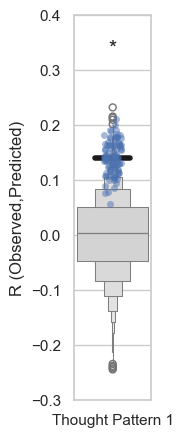

<Figure size 640x480 with 0 Axes>

In [9]:
get_boxen_plot('Thought Pattern 1')

In [10]:
def get_obs_vs_pred(behavior):
    behav_obs_pred = pd.DataFrame(real_predictions_xr.median(dim='Iteration').loc[behavior,:,['observed','predicted (glm)']], 
                                  columns=['observed','predicted (glm)'])
    fig,ax = plt.subplots(1,1,figsize=(5,5))
    r,p = plot_predictions(behav_obs_pred, ax=ax,
                       xlabel='Observed [%s]' % behavior, 
                       ylabel='Predicted [%s]' % behavior, 
                       font_scale=1,p_value=p_values.loc[behavior,'Non Parametric'])
    plt.close()
    return fig

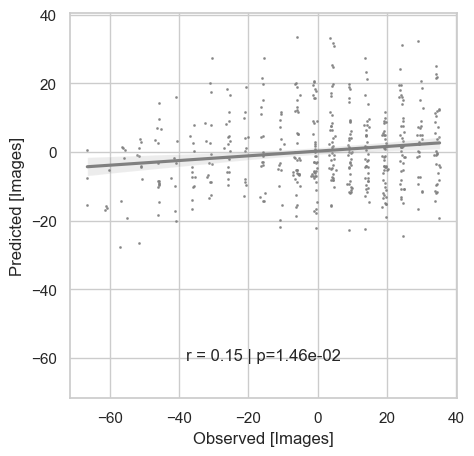

In [11]:
get_obs_vs_pred('Images')

# 2. Load CPM Network Models

First, we just load one model as a reference to infer the number of edges. We need this to create empty datastructures that will subsequently populate

In [12]:
ref_path = osp.join(RESOURCES_CPM_DIR,'swarm_outputs','real',ATLAS,SPLIT_MODE, CONFOUNDS,CORR_TYPE+'_'+E_SUMMARY_METRIC,'Images','cpm_Images_rep-{r}.pkl'.format(r=str(1).zfill(5)))
print(ref_path)
ref_data = pd.read_pickle(ref_path)
#with open(ref_path,'rb') as f:
#    ref_data = pickle.load(f)
n_edges = ref_data['models']['pos'].shape[1]

/data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/cpm/swarm_outputs/real/Schaefer2018_400Parcels_7Networks_AAL2/subject_aware/conf_residualized/pearson_sum/Images/cpm_Images_rep-00001.pkl


In [13]:
n_edges

72010

## 2.1. Load ROI Information

Next, we load the dtaframe with information about the different ROIs: labels, network membership, centroid, color

In [14]:
ATLASINFO_PATH = osp.join(ATLASES_DIR,ATLAS,f'{ATLAS}.roi_info.csv')
roi_info       = pd.read_csv(ATLASINFO_PATH)

And get a list of available networks

In [ ]:
nw_list = list(roi_info['Network'].unique())
print(nw_list)

['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default', 'Subcortical']


## 2.2. Load models for all prediction targets

> **NOTE:** Run only one of the two cells in this subsection. See below

If new results are available run the following cell, which takes time, but will load all results into memory. It will also save a pickle file with the new results. That way on successive runs of the notebook you won't have to wait for this cell to complete. Alternatively, you could run the cell below, which looks for the fila and loads it into memory

In [16]:
%%time
models = {}
models_to_vis = {}
for BEHAVIOR in BEHAVIOR_LIST:
    models = {(BEHAVIOR_LIST_LABELS[BEHAVIOR],'pos'):pd.DataFrame(index=range(CPM_NITERATIONS), columns=range(n_edges)),
              (BEHAVIOR_LIST_LABELS[BEHAVIOR],'neg'):pd.DataFrame(index=range(CPM_NITERATIONS), columns=range(n_edges))}
    df = pd.DataFrame(index=range(CPM_NITERATIONS),columns=['pos','neg','glm'])
    for r in tqdm(range(CPM_NITERATIONS), desc='Iteration [%s]' % BEHAVIOR_LIST_LABELS[BEHAVIOR]):
        path = osp.join(RESOURCES_CPM_DIR,'swarm_outputs','real',ATLAS,SPLIT_MODE, CONFOUNDS,CORR_TYPE+'_'+E_SUMMARY_METRIC,BEHAVIOR,'cpm_{b}_rep-{r}.pkl'.format(b=BEHAVIOR,r=str(r+1).zfill(5)))
        data = pd.read_pickle(path)
        #with open(path,'rb') as f:
        #    data = pickle.load(f)
        # We first averaged the number of times an edge was selected within each 10-fold run (resulting in a number between 0 and 1 for each edge)
        for tail in ['pos','neg']:
            models[BEHAVIOR_LIST_LABELS[BEHAVIOR],tail].loc[r,:] = data['models'][tail].mean(axis=0)
    # and then averaged those fractions across all 100 train-test split iterations
    models_to_vis[BEHAVIOR_LIST_LABELS[BEHAVIOR],'pos'] = models[BEHAVIOR_LIST_LABELS[BEHAVIOR],'pos'].mean()   
    models_to_vis[BEHAVIOR_LIST_LABELS[BEHAVIOR],'neg'] = models[BEHAVIOR_LIST_LABELS[BEHAVIOR],'neg'].mean()   

Iteration [Specific]: 100%|██████████| 100/100 [00:07<00:00, 13.10it/s]


CPU times: user 3min 47s, sys: 14.6 s, total: 4min 2s
Wall time: 5min 11s


In [17]:
if not osp.exists('../resources/cpm/plot_tmp/'):
    os.makedirs('../resources/cpm/plot_tmp/')
data_to_disk = {'models':models, 'models_to_vis':models_to_vis}
out_path     = '../resources/cpm/plot_tmp/models.pkl'
with open(out_path,'wb') as f:
    pickle.dump(data_to_disk,f)

Alternative cell that loads previous results. Much faster, but will not take into account potential new results.

In [18]:
out_path     = '../resources/cpm/plot_tmp/models.pkl'
with open(out_path,'rb') as f:
    data_to_disk = pickle.load(f)
models = data_to_disk['models']
models_to_vis = data_to_disk['models_to_vis']
del data_to_disk

In [19]:
BEHAVIOR_LIST_LABELS.values()

dict_values(['Thought Pattern 1', 'Thought Pattern 2', 'Wakefulness', 'Images', 'Words', 'People', 'Myself', 'Positive', 'Negative', 'Surroundings', 'Intrusive', 'Future', 'Past', 'Specific'])

## 2.3. Compute consensus models for plotting

In [20]:
thresh           = 0.9
model_consensus,num_edges_toshow,model_consensus_to_plot  = {},{},{}
for BEHAVIOR in BEHAVIOR_LIST_LABELS.values():
    for tail in ['pos','neg']:
        edge_frac                       = models_to_vis[BEHAVIOR,tail]
        model_consensus[BEHAVIOR,tail]  = (edge_frac>=thresh).astype(int)
        num_edges_toshow[BEHAVIOR,tail] = model_consensus[BEHAVIOR,tail].sum()
        print("For the [{behav},{tail}], {edges} edges were selected in at least {pct}% of folds".format(behav=BEHAVIOR,tail=tail, edges=num_edges_toshow[BEHAVIOR,tail], pct=thresh*100))
    model_consensus_to_plot[BEHAVIOR] = pd.DataFrame(squareform(model_consensus[BEHAVIOR,'pos'])-squareform(model_consensus[BEHAVIOR,'neg']),
                          index = roi_info.set_index(['ROI_ID','ROI_Name','Hemisphere','Network','RGB']).index,
                          columns= roi_info.set_index(['ROI_ID','ROI_Name','Hemisphere','Network','RGB']).index)

For the [Thought Pattern 1,pos], 204 edges were selected in at least 90.0% of folds
For the [Thought Pattern 1,neg], 675 edges were selected in at least 90.0% of folds
For the [Thought Pattern 2,pos], 1216 edges were selected in at least 90.0% of folds
For the [Thought Pattern 2,neg], 411 edges were selected in at least 90.0% of folds
For the [Wakefulness,pos], 1928 edges were selected in at least 90.0% of folds
For the [Wakefulness,neg], 1872 edges were selected in at least 90.0% of folds
For the [Images,pos], 338 edges were selected in at least 90.0% of folds
For the [Images,neg], 511 edges were selected in at least 90.0% of folds
For the [Words,pos], 115 edges were selected in at least 90.0% of folds
For the [Words,neg], 1517 edges were selected in at least 90.0% of folds
For the [People,pos], 88 edges were selected in at least 90.0% of folds
For the [People,neg], 1092 edges were selected in at least 90.0% of folds
For the [Myself,pos], 2054 edges were selected in at least 90.0% of 

In [21]:
num_edges_toshow_DF = pd.Series(num_edges_toshow).reset_index()
num_edges_toshow_DF.columns = ['Target','Network','# Edges']
num_edges_toshow_DF.set_index(['Target','Network'],inplace=True)
num_edges_toshow_DF.groupby('Target').sum()

,# Edges
Target,
Future,1036
Images,849
Intrusive,1842
Myself,2075
Negative,1067
Past,939
People,1180
Positive,2036
Specific,507


# Saving Results for CONN visualizations
We also write the models to disk in a form that we can later load in CONN

In [22]:
for BEHAVIOR in BEHAVIOR_LIST_LABELS.values():
    aux_fc = model_consensus_to_plot[BEHAVIOR]
    aux_fc_path = osp.join(RESOURCES_CONN_DIR,f'CPM_{BEHAVIOR}_matrix.txt')
    np.savetxt(aux_fc_path,aux_fc.values)
    print("++ INFO [CONN OUTPUTS] Saving matrix model to %s" % aux_fc_path)

++ INFO [CONN OUTPUTS] Saving matrix model to /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/conn/CPM_Thought Pattern 1_matrix.txt
++ INFO [CONN OUTPUTS] Saving matrix model to /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/conn/CPM_Thought Pattern 2_matrix.txt
++ INFO [CONN OUTPUTS] Saving matrix model to /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/conn/CPM_Wakefulness_matrix.txt
++ INFO [CONN OUTPUTS] Saving matrix model to /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/conn/CPM_Images_matrix.txt
++ INFO [CONN OUTPUTS] Saving matrix model to /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/conn/CPM_Words_matrix.txt
++ INFO [CONN OUTPUTS] Saving matrix model to /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/conn/CPM_People_matrix.txt
++ INFO [CONN OUTPUTS] Saving matrix model to /data/SFIMJGC_Introspe

Create extra files that are ATLAS specific so that we can plot results in CONN

In [23]:
roi_info['ROI_Name'].to_csv(osp.join(RESOURCES_CONN_DIR,'roi_labels.txt'),header=None, index=None)

In [24]:
roi_info[['pos_R','pos_A','pos_S']].to_csv(osp.join(RESOURCES_CONN_DIR,'roi_coords.txt'),header=None, index=None)

In [ ]:
(roi_info[['color_R','color_G','color_B']]/256).round(2).to_csv(osp.join(RESOURCES_CONN_DIR,'roi_colors.txt'),header=None, index=None)

***
# 3. Create Dashboard

1. Estimate the limits for the colorbar in the NW summary view (connection count mode)

In [ ]:
max_counts = []
for BEHAVIOR in BEHAVIOR_LIST_LABELS.values():
    a = model_consensus_to_plot[BEHAVIOR].abs().groupby('Network').sum().T.groupby('Network').sum()
    for n in a.index:
        a.loc[n,n] = int(a.loc[n,n]/2)
    max_counts.append(a.max().max())
max_counts = np.array(max_counts)
nw_count_max = int(np.quantile(max_counts,.9))

2. Create a drop box with all Questions

In [27]:
behav_select     = pn.widgets.Select(name='Questions',options=list(BEHAVIOR_LIST_LABELS.values()),value='Images')
cmap_pos_select  = pn.widgets.Select(name='Colormap for Positive Matrix', options=['Greys', 'Purples', 'Blues', 'Greens', 'Oranges', 'Reds',
                      'YlOrBr', 'YlOrRd', 'OrRd', 'PuRd', 'RdPu', 'BuPu',
                      'GnBu', 'PuBu', 'YlGnBu', 'PuBuGn', 'BuGn', 'YlGn','viridis', 'plasma', 'inferno', 'magma', 'cividis',
                      'binary', 'gist_yarg', 'gist_gray', 'gray', 'bone',
                      'pink', 'spring', 'summer', 'autumn', 'winter', 'cool',
                      'Wistia', 'hot', 'afmhot', 'gist_heat', 'copper'], value='Reds') 
cmap_neg_select  = pn.widgets.Select(name='Colormap for Negative Matrix', options=['Greys', 'Purples', 'Blues', 'Greens', 'Oranges', 'Reds',
                      'YlOrBr', 'YlOrRd', 'OrRd', 'PuRd', 'RdPu', 'BuPu',
                      'GnBu', 'PuBu', 'YlGnBu', 'PuBuGn', 'BuGn', 'YlGn','viridis', 'plasma', 'inferno', 'magma', 'cividis',
                      'binary', 'gist_yarg', 'gist_gray', 'gray', 'bone',
                      'pink', 'spring', 'summer', 'autumn', 'winter', 'cool',
                      'Wistia', 'hot', 'afmhot', 'gist_heat', 'copper'], value='Blues') 
matrix_max_count = pn.widgets.IntSlider(name='Max Num Conns:',start=10, end=300, step=5, value=100)
menu_tab         = pn.Column(behav_select,cmap_pos_select,cmap_neg_select, matrix_max_count)

3. Create all elements of the dashboard

In [29]:
circos_show_pos_cb   = pn.widgets.Checkbox(name='Show postively correlated edges', value=True)
circos_show_neg_cb   = pn.widgets.Checkbox(name='Show negatively correlated edges', value=True)
circos_show_degree   = pn.widgets.Checkbox(name='Node Size as a function of degree', value=True)
circos_layout        = pn.widgets.Select(name='Layout', options=['circos','spring','spectral','kamada_kawai'], value='circos')
@pn.depends(behav_select,circos_show_pos_cb,circos_show_neg_cb,circos_layout,circos_show_degree)
def gather_circos_plot(behavior, show_pos, show_neg, layout,show_degree, show_hemi_labels=True):
    #return plot_as_circos(model_consensus_to_plot[behavior],roi_info,figsize=(8,8),edge_weight=1, title=behavior, show_pos=show_pos, show_neg=show_neg)
    return plot_as_graph(model_consensus_to_plot[behavior],figsize=(12,12),edge_weight=.5, title=behavior, show_pos=show_pos, show_neg=show_neg, 
                         pos_edges_color='#640900', neg_edges_color='#090064', layout=layout, show_degree=show_degree, show_hemi_labels=show_hemi_labels)
circos_tab = pn.Column(circos_show_pos_cb,circos_show_neg_cb,gather_circos_plot, circos_show_degree,circos_layout)

In [30]:
@pn.depends(behav_select)
def gather_interactive_brain_view(behavior):
    G = nx.from_pandas_adjacency(model_consensus_to_plot[behavior].abs())
    d = [val for node,val in G.degree()]
    fig, ax = plt.subplots(1,1,figsize=(20,10))
    plot = plot_connectome(model_consensus_to_plot[behavior],roi_info[['pos_R','pos_A','pos_S']], node_color=roi_info['RGB'], node_size=d, axes=ax) #, linewidth=1, colorbar_fontsize=10, node_size=d)
    return plot

In [31]:
@pn.depends(behav_select, cmap_pos_select, cmap_neg_select, matrix_max_count)
def gather_nw_matrix(behavior, pos_cmap, neg_cmap, clim_max_count, clim_min_count=0, add_net_labels=True):
    pos_count = hvplot_fc_nwlevel(model_consensus_to_plot[behavior]>0,title='Positive Correlation',mode='count', add_net_colors=True, add_net_labels=add_net_labels, cmap=pos_cmap, labels_text_color='red', clim_min=clim_min_count, clim_max=clim_max_count).opts(toolbar=None) #cmap='Reds'
    neg_count = hvplot_fc_nwlevel(model_consensus_to_plot[behavior]<0,title='Negative Correlation',mode='count', add_net_colors=True, add_net_labels=add_net_labels, cmap=neg_cmap, labels_text_color='blue', clim_min=clim_min_count, clim_max=clim_max_count).opts(toolbar=None)
    all_count = hvplot_fc_nwlevel(model_consensus_to_plot[behavior].abs(),title='Full Model',mode='count', add_net_colors=True).opts(toolbar=None)
    count_card = pn.Card(pn.Row(pos_count,neg_count,all_count), title='Number of Edges', width=2200)
    
    pos_pcent = hvplot_fc_nwlevel(model_consensus_to_plot[behavior]>0,title='Positive Correlation',add_net_colors=True, cmap=pos_cmap, add_net_labels=add_net_labels, clim_max=15, labels_text_color='red').opts(toolbar=None)
    neg_pcent = hvplot_fc_nwlevel(model_consensus_to_plot[behavior]<0,title='Negative Correlation',add_net_colors=True, cmap=neg_cmap, add_net_labels=add_net_labels, clim_max=15, labels_text_color='blue').opts(toolbar=None)
    all_pcent = hvplot_fc_nwlevel(model_consensus_to_plot[behavior].abs(),title='Full Model',add_net_colors=True, clim_max=15).opts(toolbar=None)
    pcent_card = pn.Card(pn.Row(pos_pcent,neg_pcent,all_pcent), title='Percentage of Edges', width=2200)
    return pn.Column(count_card, pcent_card)

In [32]:
@pn.depends(behav_select)
def get_pred_plots(behavior):
    return pn.Card(pn.Row(pn.pane.Matplotlib(get_boxen_plot(behavior), width=150, height=420,tight=True), 
        pn.pane.Matplotlib(get_obs_vs_pred(behavior), width=420, height=420,tight=True)),
        title='Prediction Power')

In [33]:
nws_group_from = pn.widgets.CheckBoxGroup(name='Networks', value=nw_list, options=nw_list, inline=True)
nws_group_to   = pn.widgets.CheckBoxGroup(name='Networks', value=nw_list, options=nw_list, inline=True)
only_sel_nw    = pn.widgets.Checkbox(name='Show nodes for selected networks only', value=False)

In [34]:
@pn.depends(behav_select,nws_group_from,nws_group_to,only_sel_nw)
def plot_brain_model(behavior,sel_nws_from,sel_nws_to,sel_nws_only):
    fig, ax = plt.subplots(1,1,figsize=(20,10))
    ax.grid(False)
    ax.axis(False)
    sel_nws_union = list(set(sel_nws_from+sel_nws_to)) 
    sel_rois_info = roi_info.copy()
    full_model         = model_consensus_to_plot[behavior].copy()
    plot_model        = pd.DataFrame(0, index=full_model.index.get_level_values('ROI_ID'), columns=full_model.columns.get_level_values('ROI_ID'))
    for nwf in sel_nws_from:
        for nwt in sel_nws_to:
            index_ = full_model.loc[:,:,:,nwf,:].index
            col_   = full_model.T.loc[:,:,:,nwt,:].index
            plot_model.loc[index_.get_level_values('ROI_ID'),col_.get_level_values('ROI_ID')] = full_model.loc[:,:,:,nwf,:].T.loc[:,:,:,nwt,:].T.values
            plot_model.loc[col_.get_level_values('ROI_ID'),index_.get_level_values('ROI_ID')] = full_model.loc[:,:,:,nwt,:].T.loc[:,:,:,nwf,:].T.values
    plot_model.index = full_model.index
    plot_model.columns = full_model.columns
    
    #if sel_nws_only is True:
    #    plot_model    = plot_model.loc[:,:,:,sel_nws_union,:].T.loc[:,:,:,sel_nws_union,:]
    #    sel_rois_info = sel_rois_info.set_index('Network').loc[sel_nws_union]
        
        
    # ==============
    G,Gnt = create_graph_from_matrix(plot_model)
    #print(G)
    #Gnt = node_table(G).sort_index() #[::-1]
    # ==============
    brain_view = plot_connectome(adjacency_matrix=plot_model, 
                                     node_coords=sel_rois_info[['pos_R', 'pos_A','pos_S']],
                                     node_color=sel_rois_info['RGB'],node_size=5*Gnt['Degree'],
                                     edge_kwargs={'linewidth':0.5},
                                     node_kwargs={'edgecolor':'k', 'linewidth':0.5},
                                     figure=fig)
    plt.close()
    return pn.pane.Matplotlib(fig)

In [35]:
@pn.depends(behav_select)
def get_conn_counts(behavior):
    posconns = (model_consensus_to_plot[behavior]>0).groupby('Network').sum().T.groupby('Network').sum().loc[['Vis','SomMot','DorsAttn','SalVentAttn','Limbic','Cont','Default','Subcortical'],['Vis','SomMot','DorsAttn','SalVentAttn','Limbic','Cont','Default','Subcortical']]
    for nw in nw_list:
        posconns.loc[nw,nw] = posconns.loc[nw,nw] / 2
    posconns_final = posconns.sum()
    posconns_final.name = '# Conns'
    posconns_final['Total'] = int((model_consensus_to_plot[behavior]>0).sum().sum()/2)
    negconns = (model_consensus_to_plot[behavior]<0).groupby('Network').sum().T.groupby('Network').sum().loc[['Vis','SomMot','DorsAttn','SalVentAttn','Limbic','Cont','Default','Subcortical'],['Vis','SomMot','DorsAttn','SalVentAttn','Limbic','Cont','Default','Subcortical']]
    for nw in nw_list:
        negconns.loc[nw,nw] = negconns.loc[nw,nw] / 2
    negconns_final = negconns.sum()
    negconns_final.name = '# Conns'
    negconns_final['Total'] = int((model_consensus_to_plot[behavior]<0).sum().sum()/2)
    return pn.Card(pn.Row(pn.Column(pn.pane.Markdown('### Positive Connections'),pn.pane.DataFrame(posconns_final)),
       pn.Column(pn.pane.Markdown('### Negative Connections'),pn.pane.DataFrame(negconns_final))),title='CPM Model | Connection Counts')

In [36]:
@pn.depends(behav_select)
def get_top10degree_counts(behavior):
    aux_pos      = (model_consensus_to_plot[behavior]>0).sum().sort_values(ascending=False)[0:10]
    aux_pos.name = 'Degree'
    aux_pos      = pd.DataFrame(aux_pos).reset_index()
    nodes_pos    = aux_pos['ROI_ID'].values.astype(int)
    aux_pos      = aux_pos.drop(['RGB','ROI_ID'],axis=1)
    aux_pos.index = aux_pos.index + 1
    aux_pos.index.name = 'Ranking'

    aux_pos['ROI_Name'] = ['-'.join(i.split('_')[2:]) for i in aux_pos['ROI_Name']]
    
    aux_neg      = (model_consensus_to_plot[behavior]<0).sum().sort_values(ascending=False)[0:10]
    aux_neg.name = 'Degree'
    aux_neg      = pd.DataFrame(aux_neg).reset_index()
    nodes_neg    = aux_neg['ROI_ID'].values.astype(int)
    aux_neg      = aux_neg.drop(['RGB','ROI_ID'],axis=1)
    aux_neg.index = aux_neg.index + 1
    aux_neg.index.name = 'Ranking'
    
    aux_neg['ROI_Name'] = ['-'.join(i.split('_')[2:]) for i in aux_neg['ROI_Name']]
    
    common_nodes = list(np.intersect1d(nodes_pos,nodes_neg))
    print(len(common_nodes))
    if len(common_nodes) > 0:
        output = pn.Card(pn.Row(pn.Column(pn.pane.Markdown('### Positive Connections'),pn.pane.DataFrame(aux_pos, width=550)),
                                pn.Column(pn.pane.Markdown('### Negative Connections'),pn.pane.DataFrame(aux_neg, width=550)), pn.pane.Markdown('> **NOTE: Overlaping nodes %s' % common_nodes)),title='CPM Model | Top 10 Degree Nodes')
    else:
        output = pn.Card(pn.Row(pn.Column(pn.pane.Markdown('### Positive Connections'),pn.pane.DataFrame(aux_pos, width=550)),
       pn.Column(pn.pane.Markdown('### Negative Connections'),pn.pane.DataFrame(aux_neg, width=550))),title='CPM Model | Top 10 Degree Nodes')
    return output

In [37]:
brain_view_tab=pn.Column(pn.Row('From:',nws_group_from, background='whitesmoke'),pn.Row('To. :',nws_group_to, background='whitesmoke'),only_sel_nw,plot_brain_model)

/tmp/ipykernel_1748903/2203230514.py:1: PanelDeprecationWarning: "Row(..., background='whitesmoke')" is deprecated and will be removed in version 1.3, use "Row(..., styles={'background': 'whitesmoke'})" instead.
  brain_view_tab=pn.Column(pn.Row('From:',nws_group_from, background='whitesmoke'),pn.Row('To. :',nws_group_to, background='whitesmoke'),only_sel_nw,plot_brain_model)
/tmp/ipykernel_1748903/2203230514.py:1: PanelDeprecationWarning: "Row(..., background='whitesmoke')" is deprecated and will be removed in version 1.3, use "Row(..., styles={'background': 'whitesmoke'})" instead.
  brain_view_tab=pn.Column(pn.Row('From:',nws_group_from, background='whitesmoke'),pn.Row('To. :',nws_group_to, background='whitesmoke'),only_sel_nw,plot_brain_model)


4. Create the dashboard

In [38]:
dashboard = pn.Row(pn.Column(menu_tab, pn.Row(get_pred_plots, 
                                              pn.Tabs(('Connection Counts',get_conn_counts),('Top 10 Degree ROIs',get_top10degree_counts))), pn.Tabs(('Circos Plot',circos_tab),('Brain View',brain_view_tab))), 
                   pn.Column(gather_nw_matrix))

1


<Figure size 640x480 with 0 Axes>

### Alternative smaller versions of the dashboard

In [43]:
dashboard_server = dashboard.show(port=port_tunnel,open=False)

Launching server at http://localhost:35707


In [44]:
# Once you are done looking at matrices, you can stop the server running this cell
dashboard_server.stop()

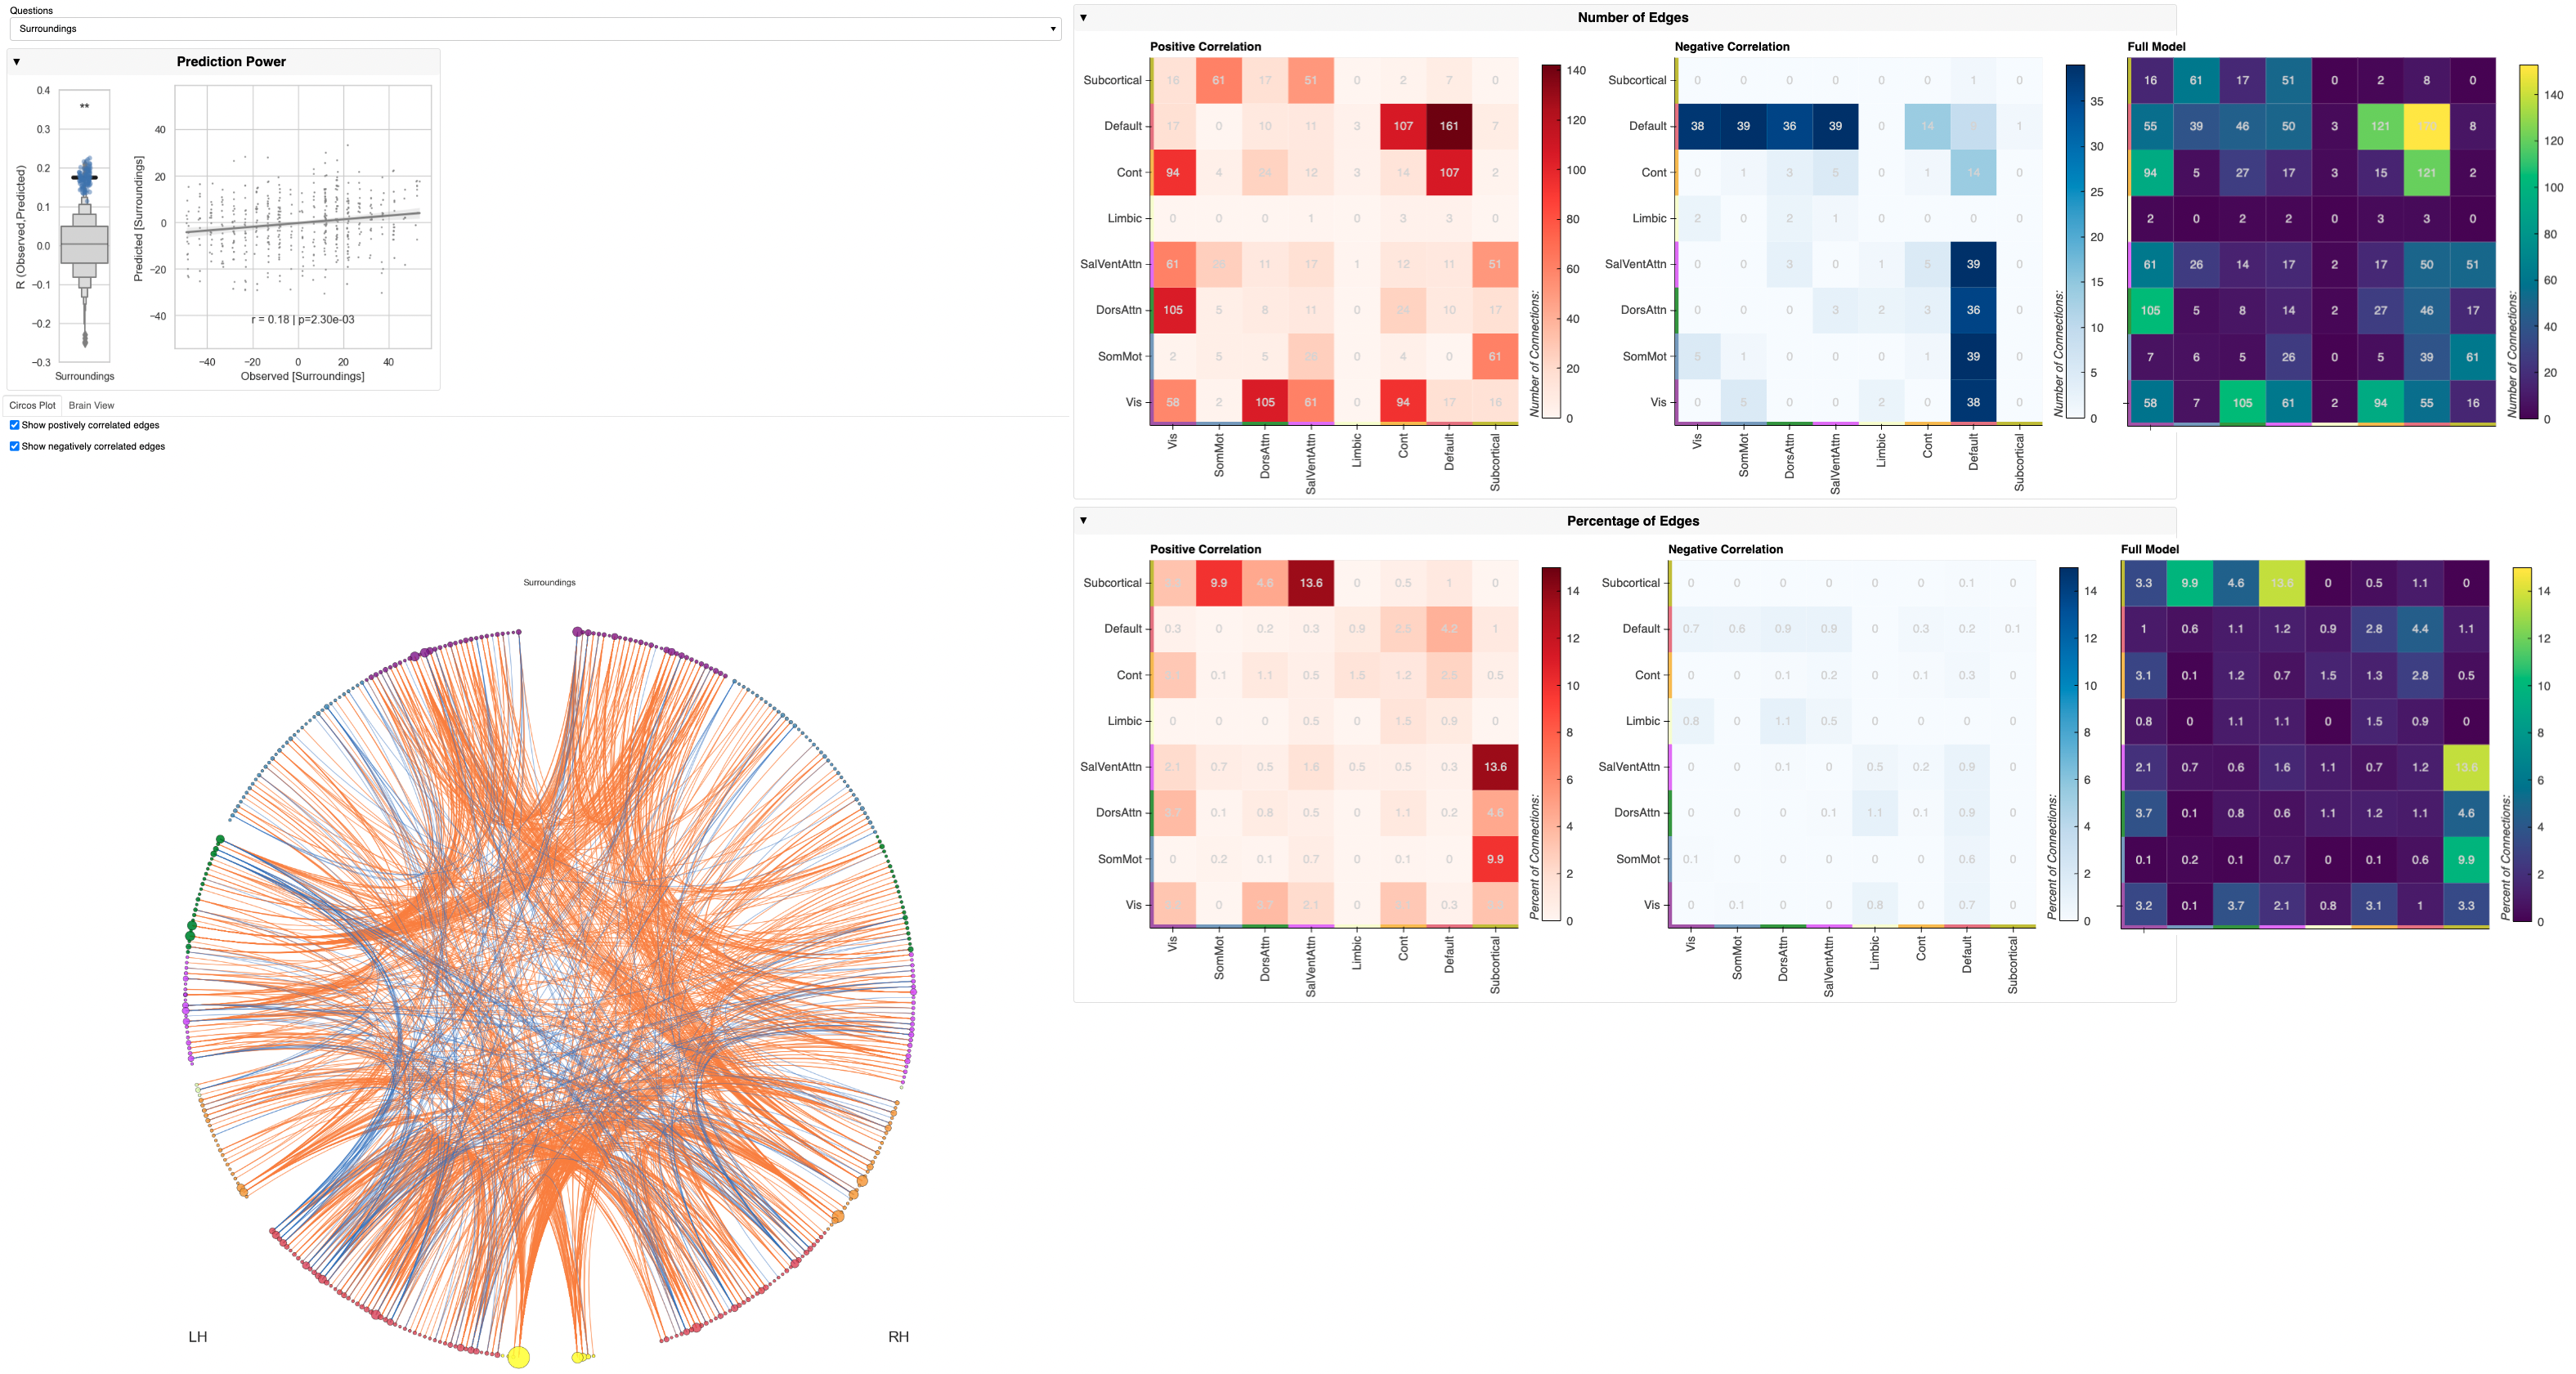

In [38]:
display.Image('./figures/S17_CPM_Dashboard_screenshot.png')